Upload a Jellyfish image


Saving IM-0006-0001opencv 2.jpeg to IM-0006-0001opencv 2.jpeg


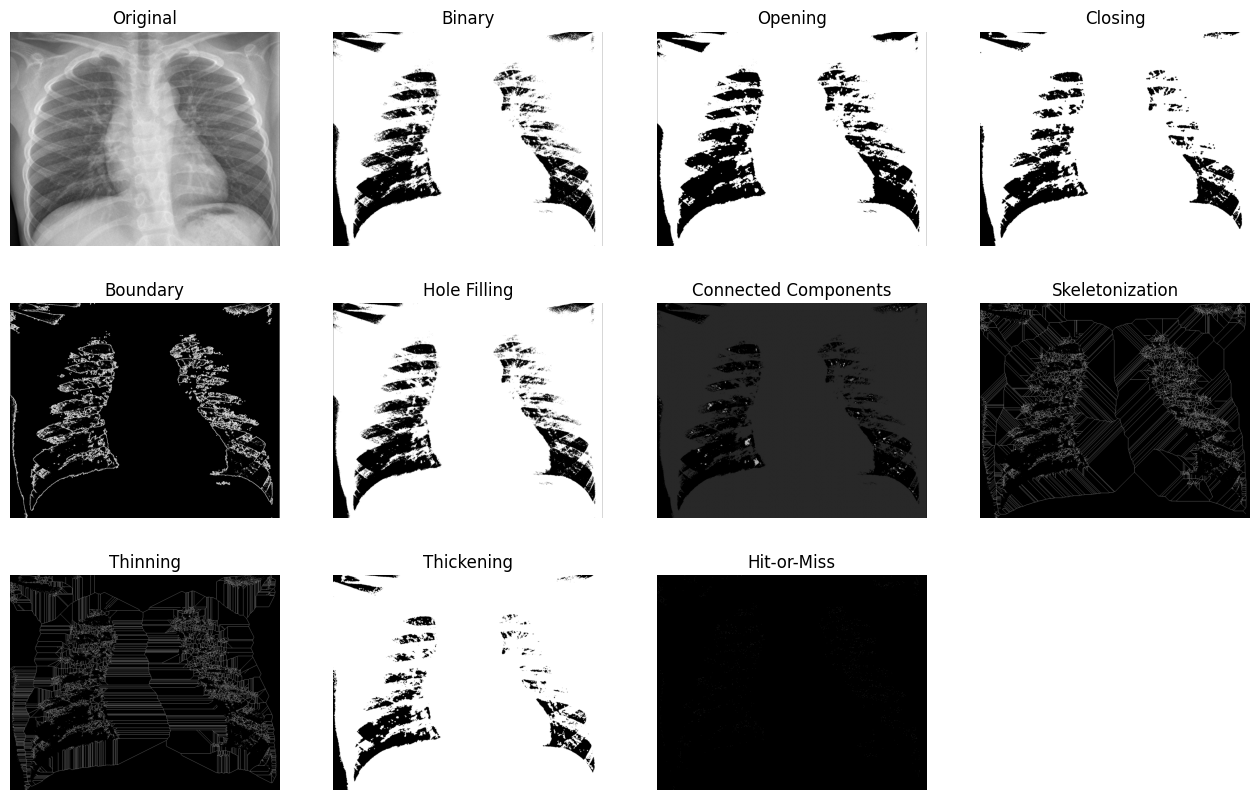

Number of Connected Components: 2481


In [4]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt
from skimage.morphology import skeletonize, thin

# Upload Jellyfish Image
print("Upload a Jellyfish image")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

# Read image
img = cv2.imread(img_name, 0)

# Convert to Binary
_, binary = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

# Kernel
kernel = np.ones((5,5), np.uint8)

# 1. Opening (Erosion → Dilation)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 2. Closing (Dilation → Erosion)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# 3. Boundary Extraction
eroded = cv2.erode(binary, kernel)
boundary = cv2.subtract(binary, eroded)

# 4. Hole Filling
inv = cv2.bitwise_not(binary)
h, w = binary.shape
mask = np.zeros((h+2, w+2), np.uint8)
flood = inv.copy()
cv2.floodFill(flood, mask, (0,0), 255)
flood_inv = cv2.bitwise_not(flood)
hole_filled = binary | flood_inv

# 5. Connected Component Labeling
num_labels, labels = cv2.connectedComponents(binary)

# Convert labels to displayable image
labels_display = (labels * 20).astype(np.uint8)

# 6. Skeletonization
skeleton = skeletonize(binary//255)
skeleton = skeleton.astype(np.uint8)*255

# 7. Thinning
thin_img = thin(binary//255)
thin_img = thin_img.astype(np.uint8)*255

# 8. Thickening (approximate using dilation)
thick = cv2.dilate(binary, kernel, iterations=1)

# 9. Hit-or-Miss Transform
kernel_hm = np.array([[0,1,0],
                      [1,-1,1],
                      [0,1,0]], dtype=np.int8)

hitmiss = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, kernel_hm)

# Display Results
titles = [
"Original","Binary",
"Opening","Closing",
"Boundary",
"Hole Filling",
"Connected Components",
"Skeletonization",
"Thinning",
"Thickening",
"Hit-or-Miss"
]

images = [
img,binary,
opening,closing,
boundary,
hole_filled,
labels_display,
skeleton,
thin_img,
thick,
hitmiss
]

plt.figure(figsize=(16,10))

for i in range(len(images)):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

print("Number of Connected Components:", num_labels)